# Scipy Functions for IIR Filter Design & Analysis

The **`scipy.signal`** submodule has **all** the major tools to **design**, **analyze**, and **implement** IIR filters

In [18]:
def plot_filter_responses(b, a, fs=1.0, title="Filter"):

    #Compute frequency response
    w, h = freqz(b, a, worN=1024)
    w_norm = w / np.pi
    # Impulse response
    impulse_len = 60
    impulse = np.zeros(impulse_len)
    impulse[0] = 1.0
    resp = lfilter(b, a, impulse)

    # Create a figure with three subplots: (Magnitude, Phase, ImpulseResponse)
    fig, axes = plt.subplots(3, 1, figsize=(7, 8))
    fig.suptitle(title, fontsize=14)

    # (A) Magnitude Response
    mag_db = 20.0 * np.log10(np.abs(h))
    axes[0].plot(w_norm, mag_db, color='b')
    axes[0].set_title("Magnitude Response (dB)")
    axes[0].set_xlabel("Normalized Frequency (rad/sample)")
    axes[0].set_ylabel("Magnitude (dB)")
    axes[0].grid(True)

    # (B) Phase Response
    phase = np.unwrap(np.angle(h))
    axes[1].plot(w_norm, phase, color='g')
    axes[1].set_title("Phase Response (radians)")
    axes[1].set_xlabel("Normalized Frequency (rad/sample)")
    axes[1].set_ylabel("Phase (radians)")
    axes[1].grid(True)

    # (C) Impulse Response
    axes[2].stem(np.arange(impulse_len), resp, basefmt=" ")
    axes[2].set_title("Impulse Response")
    axes[2].set_xlabel("n (samples)")
    axes[2].set_ylabel("Amplitude")
    axes[2].grid(True)

    plt.tight_layout()
    # Move main title slightly up
    fig.subplots_adjust(top=0.92)
    plt.show()


## Butterworth

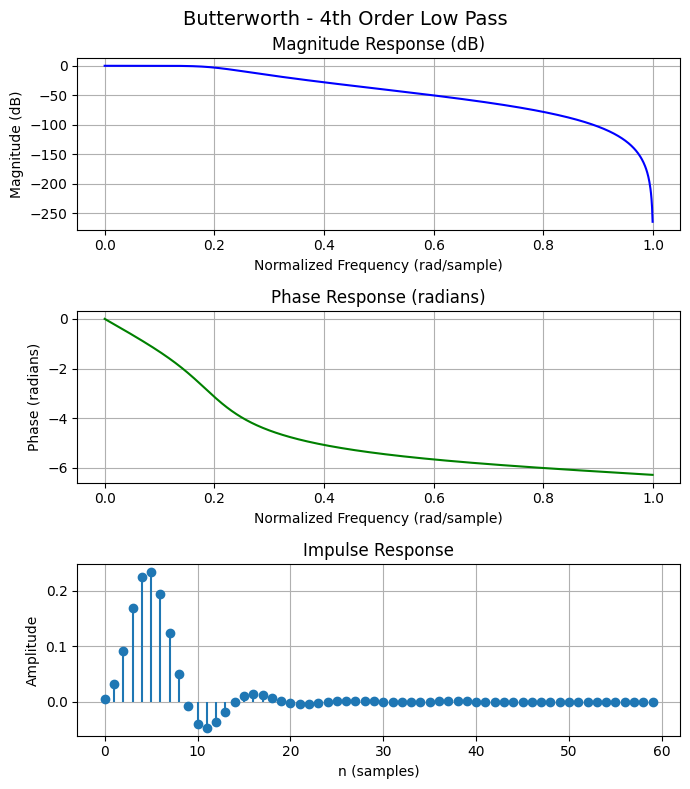

In [44]:
from scipy.signal import butter

# 4th-order Butterworth low-pass at 0.2 normalized freq (Nyquist=1)
fs = 1.0
cutoff = 0.2 
b, a = butter(N=4, Wn=cutoff, btype='low', analog=False, output='ba')
plot_filter_responses(b, a, fs=1.0, title="Butterworth - 4th Order Low Pass")

## Chebyshev

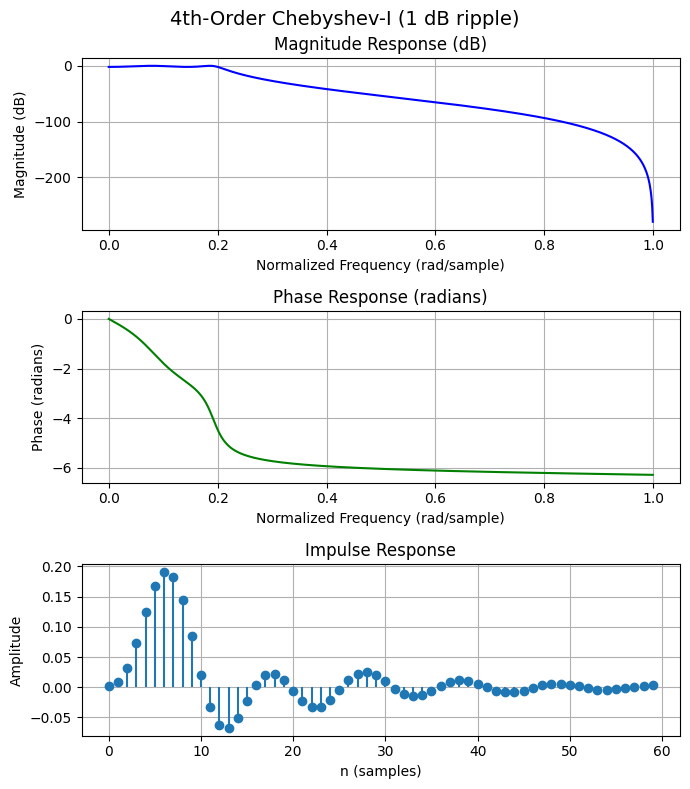

In [48]:
fs = 1.0
cutoff = 0.2 
b_cheb1, a_cheb1 = cheby1(N=4, rp=2, Wn=cutoff, btype='low', analog=False, output='ba')
plot_filter_responses(b_cheb1, a_cheb1, fs=fs, title="4th-Order Chebyshev-I (1 dB ripple)")

## General IIR filter Design

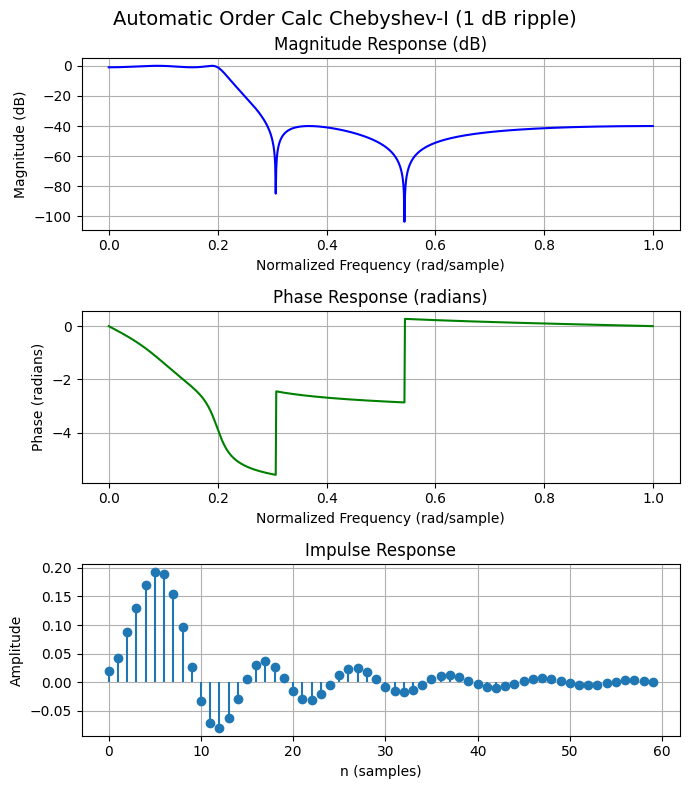

In [49]:
from scipy.signal import iirdesign

b, a = iirdesign(
    wp=0.2,       # passband edge
    ws=0.3,       # stopband edge
    gpass=1,      # passband ripple (dB)
    gstop=40,     # stopband attenuation (dB)
    ftype='ellip'
)
plot_filter_responses(b, a, fs=fs, title="Automatic Order Calc Chebyshev-I (1 dB ripple)")

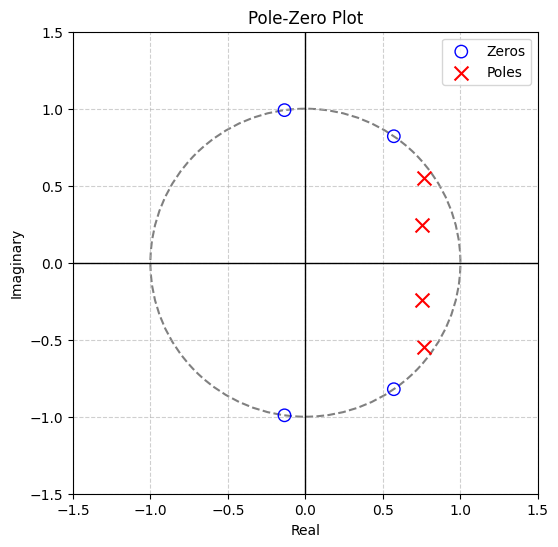

In [50]:
from scipy.signal import tf2zpk


b, a = iirdesign(
    wp=0.2,       # passband edge
    ws=0.3,       # stopband edge
    gpass=1,      # passband ripple (dB)
    gstop=40,     # stopband attenuation (dB)
    ftype='ellip'
)


z, p, k = tf2zpk(b, a)

# Create figure
fig, ax = plt.subplots(figsize=(6,6))

# Plot the unit circle correctly
unit_circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='dashed', linewidth=1.5)
ax.add_artist(unit_circle)

# Plot zeros and poles
ax.scatter(z.real, z.imag, marker='o', label='Zeros', facecolors='none', edgecolors='blue', s=80)
ax.scatter(p.real, p.imag, marker='x', label='Poles', color='red', s=100)

# Formatting the plot
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title("Pole-Zero Plot")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()


# Relevant Functions Cheat Sheet

## IIR Filter Design  
- `butter(...)` - Butterworth filter  
- `cheby1(...)` - Chebyshev Type I filter (passband ripple)  
- `cheby2(...)` - Chebyshev Type II filter (stopband ripple)  
- `ellip(...)` - Elliptic (Cauer) filter (ripple in both pass & stopband)  
- `bessel(...)` - Bessel filter (maximally flat group delay)  
- `iirfilter(...)` - General IIR filter design function  
- `iirdesign(...)` - Design based on passband/stopband constraints  

---

## Conversion Functions  
- `tf2zpk(b, a)` - Convert transfer function to zeros, poles, and gain  
- `zpk2tf(z, p, k)` - Convert zeros, poles, and gain to transfer function  
- `zpk2sos(...)` - Convert zeros/poles/gain to second-order sections (for stability)  
- `sos2zpk(...)` - Convert second-order sections back to zero-pole representation  
- `bilinear(...)` - Convert analog filter to digital via bilinear transformation  

---

## Analysis Functions  
- `freqz(b, a)` - Frequency response of IIR filter  
- `sosfreqz(sos)` - Frequency response of second-order section (sos) filter  
- `tf2zpk(...)` - Compute poles and zeros for analysis/stability  
- `lfilter(...)` - Apply filter to a signal in time-domain  
- `filtfilt(...)` - Zero-phase filtering (forward & backward)  

---

## Filter Type Options  
- `'low'` - Low-pass filter  
- `'high'` - High-pass filter  
- `'bandpass'` - Band-pass filter  
- `'bandstop'` - Band-stop (notch) filter  
- `'lowshelf'`, `'highshelf'` - Shelf filters for EQ applications  

---

## Order & Filter Parameters  
- **Typical parameters to specify:**  
  - `N` - Filter order  
  - `Wn` - Cutoff frequencies (single value for low/high, tuple for bandpass/bandstop)  
  - `rp` - Passband ripple (dB) (for Chebyshev I & Elliptic filters)  
  - `rs` - Stopband attenuation (dB) (for Chebyshev II & Elliptic filters)  
  - `btype` - Filter type (`'low'`, `'high'`, etc.)  
  - `analog` - `True` for analog filter, `False` for digital  
  - `output` - Format (`'ba'`, `'zpk'`, `'sos'`)  